# Predictive Insight Engine

📌 Problem Statement

# 🧪 Dataset Understanding & Preparation

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import time

In [5]:
df = pd.read_excel("C:/Users/MR_MAHESH/Data Science/Dataset/SL/RealEstate_HousePrice_Dataset_4200.xlsx")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (4200, 12)


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


🔍 Identify Independent and Dependent Variables

In [6]:
# Independent variables
X = df.drop(columns=['house_id','house_price_inr'])

# Dependent / Target variable
y = df['house_price_inr']

print("Independent Variables:")
print(X.columns.tolist())

print("\nDependent Variable:")
print(y.name)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Independent Variables:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']

Dependent Variable:
house_price_inr

X Shape: (4200, 10)
y Shape: (4200,)


🔍 Visualize Relationships Between Features and Target Variable

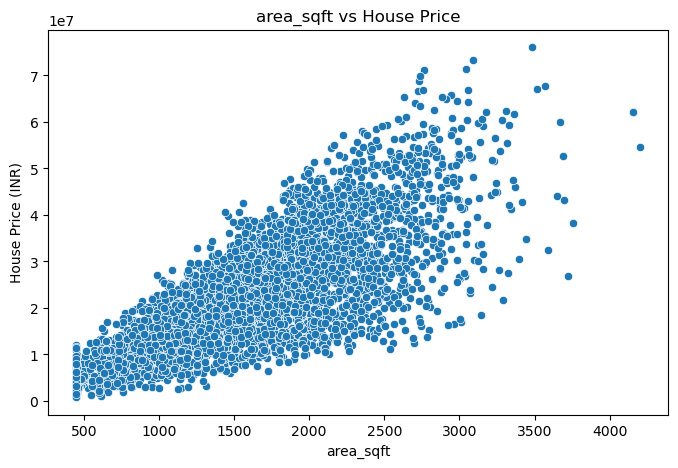

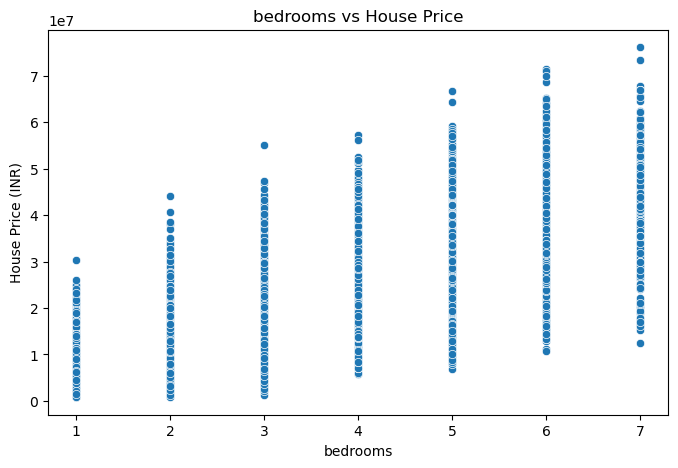

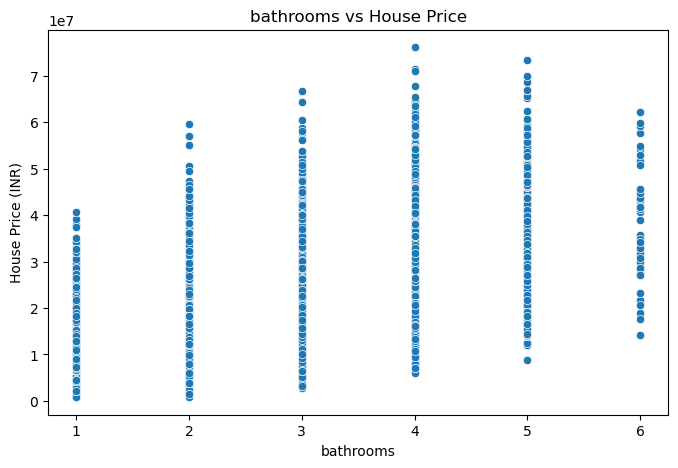

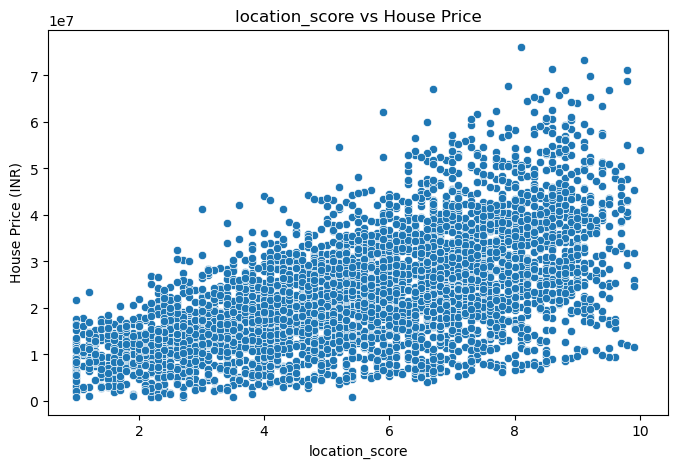

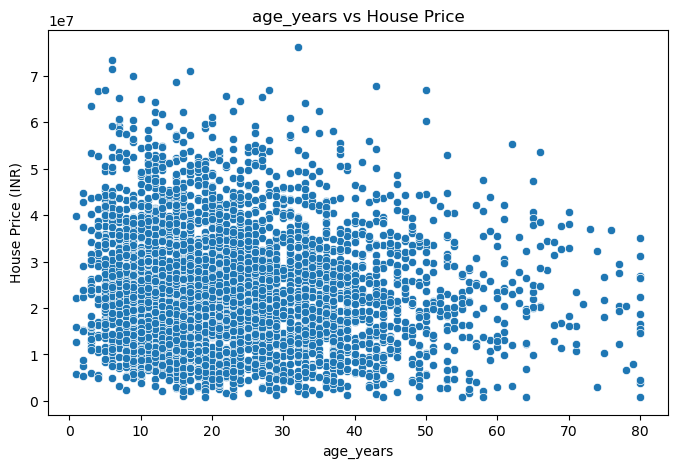

In [7]:
features = [
    'area_sqft',
    'bedrooms',
    'bathrooms',
    'location_score',
    'age_years']

for feature in features:  
    plt.figure(figsize=(8, 5))  
    sns.scatterplot(data=df,x=feature,y='house_price_inr')
    plt.title(f'{feature} vs House Price')
    plt.xlabel(feature)
    plt.ylabel('House Price (INR)')
    plt.show()

Correlation Heatmap

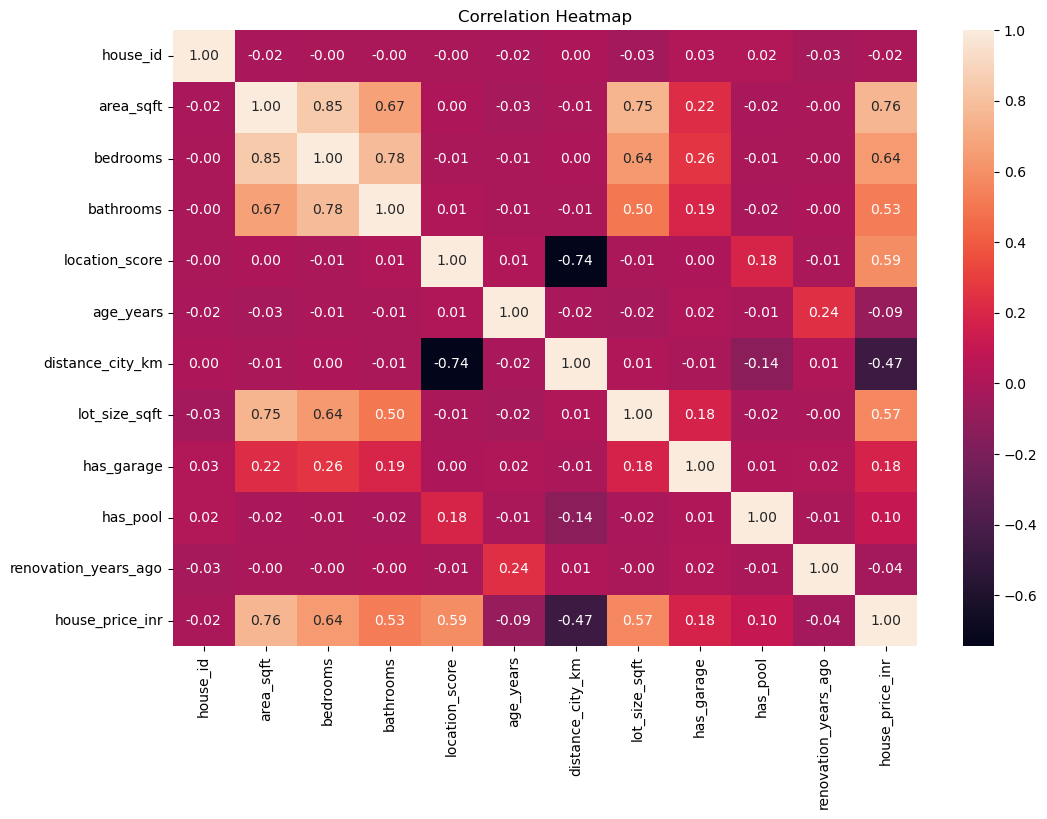

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include='number').corr(),annot=True,fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

🔍 Split Dataset into Training and Testing Sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3360, 10)
Testing Data: (840, 10)


# 📈  Simple Linear Regression

🔍Implement Simple Linear Regression Using House Area

In [12]:
X_simple = df[['area_sqft']]
y_simple = df['house_price_inr']


X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,y_simple,
    test_size=0.20,
    random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train_simple,y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)
print("Simple Linear Regression trained successfully.")

Simple Linear Regression trained successfully.


🔍 Plot Regression Line and Interpret Slope and Intercept

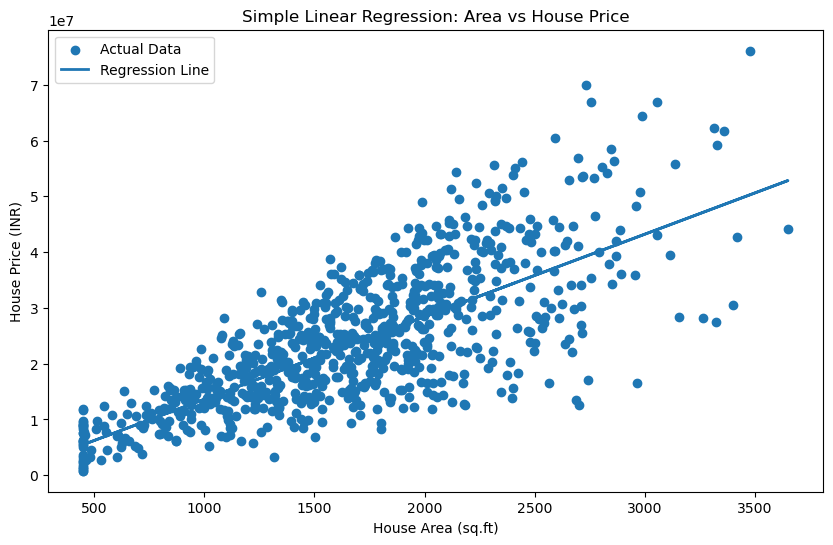

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple['area_sqft'],y_test_simple,label='Actual Data')
plt.plot(
    X_test_simple['area_sqft'],
    y_pred_simple,
    linewidth=2,
    label='Regression Line')
plt.xlabel('House Area (sq.ft)')
plt.ylabel('House Price (INR)')
plt.title('Simple Linear Regression: Area vs House Price')
plt.legend()
plt.show()

Slope and Intercept

In [15]:
slope = simple_model.coef_[0]
intercept = simple_model.intercept_
print("Slope:", slope)
print("Intercept:", intercept)
print(f"\nEquation: House Price = {intercept:.2f} + "f"({slope:.2f} × Area)")

Slope: 14788.306111307538
Intercept: -1163519.1764186062

Equation: House Price = -1163519.18 + (14788.31 × Area)


🔍 Validate Linear Regression Assumptions Using Plots and Observations

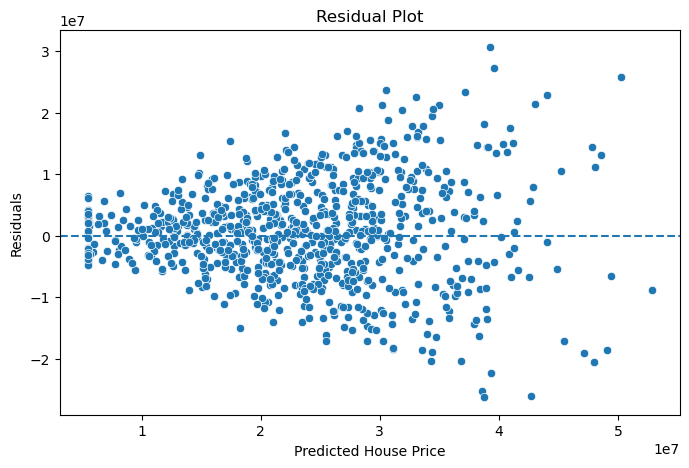

In [16]:
residuals = y_test_simple - y_pred_simple
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_simple,y=residuals)
plt.axhline(y=0,linestyle='--')
plt.xlabel('Predicted House Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Residual Distribution

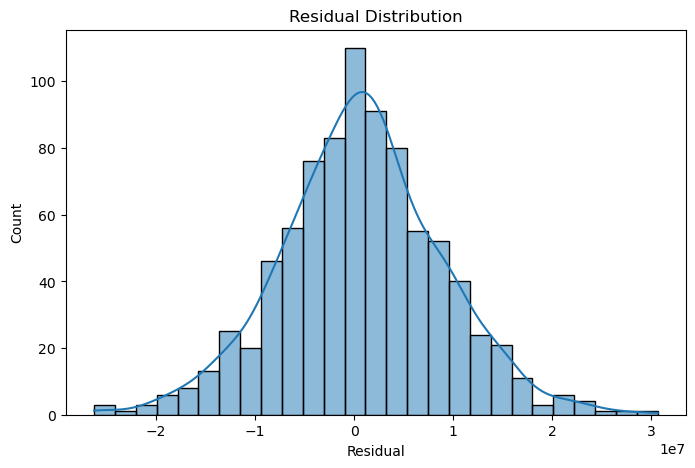

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals,kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.show()

Q-Q Plot

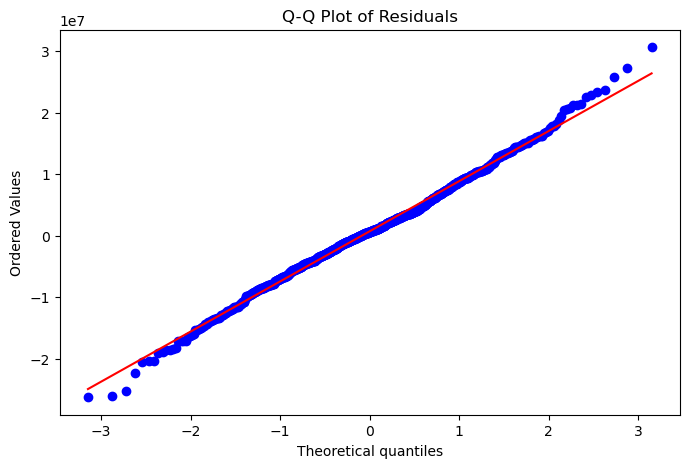

In [18]:
import scipy.stats as stats
plt.figure(figsize=(8, 5))
stats.probplot(residuals,dist="norm",plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 📊 Model Evaluation Metrics

 🔍 Evaluate Simple Linear Regression Model

In [19]:
mse = mean_squared_error(y_test_simple,y_pred_simple)
mae = mean_absolute_error(y_test_simple,y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_simple,y_pred_simple)
n = len(y_test_simple)
p = X_test_simple.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

simple_metrics = pd.DataFrame({'Metric': [
        'MSE',
        'MAE',
        'RMSE',
        'R² Score',
        'Adjusted R²'],'Value': [
        mse,
        mae,
        rmse,
        r2,
        adjusted_r2]})

display(simple_metrics)

,Metric,Value
0,MSE,6.698926e+13
1,MAE,6.294594e+06
2,RMSE,8.184697e+06
3,R² Score,5.625200e-01
4,Adjusted R²,5.619979e-01


Interpret Each Metric

# 📉 Multiple Linear Regression

🔍 Implement Multiple Linear Regression Using All Relevant Features

In [20]:
X = df.drop(columns=['house_id','house_price_inr'])

y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

multiple_model = LinearRegression()
multiple_model.fit(X_train,y_train)

y_pred_multiple = multiple_model.predict(X_test)
print("Multiple Linear Regression trained successfully.")

Multiple Linear Regression trained successfully.


🔍 Compare Multiple Regression with Simple Linear Regression

In [21]:
def calculate_metrics(y_true, y_pred, n_features): 
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) /(n - n_features - 1)) 
    return [mse,mae,rmse,r2,adjusted_r2]

simple_result = calculate_metrics(y_test_simple,y_pred_simple,1)

multiple_result = calculate_metrics(y_test,y_pred_multiple,X_test.shape[1])

comparison = pd.DataFrame(
    [simple_result, multiple_result],
    columns=['MSE','MAE','RMSE','R²','Adjusted R²'],
    index=['Simple Linear Regression','Multiple Linear Regression'])
display(comparison)

,MSE,MAE,RMSE,R²,Adjusted R²
Simple Linear Regression,6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
Multiple Linear Regression,1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769


🔍 Explain Why Performance Improves or Degrades

# 🔁 Polynomial Regression

🔍 Implement Polynomial Regression Degree 2

In [22]:
X_poly = df[['area_sqft']]
y_poly = df['house_price_inr']

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly,y_poly,test_size=0.20,random_state=42)

poly_model = Pipeline([('polynomial', PolynomialFeatures(degree=2)), ('linear', LinearRegression())])

poly_model.fit(X_train_poly,y_train_poly)
y_pred_poly = poly_model.predict(X_test_poly)
print("Polynomial Regression Degree 2 trained successfully.")

Polynomial Regression Degree 2 trained successfully.


🔍 Compare Linear vs Polynomial Regression Visually and Numerically

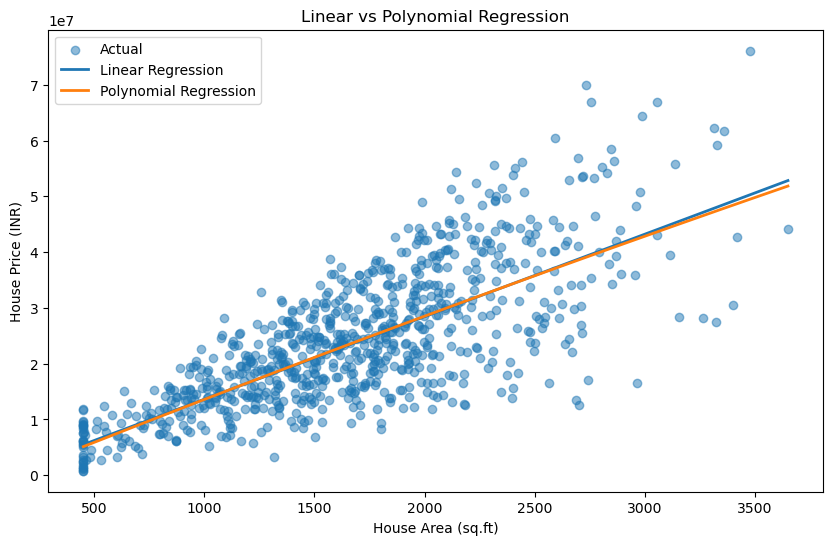

In [23]:
sort_index = X_test_poly['area_sqft'].argsort()

X_sorted = X_test_poly.iloc[sort_index]
y_poly_sorted = y_pred_poly[sort_index]
y_linear_sorted = simple_model.predict(X_sorted)
plt.figure(figsize=(10, 6))
plt.scatter(X_test_poly['area_sqft'],y_test_poly,alpha=0.5,label='Actual')
plt.plot(X_sorted['area_sqft'],y_linear_sorted,linewidth=2,label='Linear Regression')
plt.plot(X_sorted['area_sqft'],y_poly_sorted,linewidth=2,label='Polynomial Regression')
plt.xlabel('House Area (sq.ft)')
plt.ylabel('House Price (INR)')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

Numerical Comparison

In [24]:
poly_r2 = r2_score(y_test_poly,y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test_poly,y_pred_poly))
print("Polynomial R²:", poly_r2)
print("Polynomial RMSE:", poly_rmse)
print("\nSimple Linear R²:", r2_score(y_test_simple,y_pred_simple))
print("Simple Linear RMSE:", np.sqrt(mean_squared_error(y_test_simple,y_pred_simple)))

Polynomial R²: 0.5626917978136464
Polynomial RMSE: 8183089.094113444

Simple Linear R²: 0.562519958799158
Simple Linear RMSE: 8184696.6969979685


🔍 Identify Signs of Overfitting or Underfitting

In [25]:
train_pred_poly = poly_model.predict(X_train_poly)
train_r2 = r2_score(y_train_poly,train_pred_poly)
test_r2 = r2_score(y_test_poly,y_pred_poly)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

if train_r2 - test_r2 > 0.10:
    print("\nPossible overfitting detected.")
elif train_r2 < 0.60 and test_r2 < 0.60:
    print("\nPossible underfitting detected.")
else:
    print("\nNo strong evidence of overfitting or underfitting.")

Training R²: 0.5724674245504779
Testing R²: 0.5626917978136464

Possible underfitting detected.


# ⚙️ Gradient Descent Optimization

🔍 Explain Gradient Descent Conceptually

🔍 Implement Batch Gradient Descent From Scratch

In [27]:
gd_features = ['area_sqft','bedrooms','bathrooms','location_score','age_years']
X_gd = df[gd_features].values
y_gd = df['house_price_inr'].values

X_train_gd, X_test_gd, y_train_gd, y_test_gd = train_test_split(X_gd,y_gd,test_size=0.20,random_state=42)

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_gd)

X_test_scaled = scaler_X.transform(X_test_gd)

y_mean = y_train_gd.mean()
y_std = y_train_gd.std()

y_train_scaled = (y_train_gd - y_mean) / y_std

y_test_scaled = (y_test_gd - y_mean) / y_std

Batch Gradient Descent Function

In [28]:
def batch_gradient_descent(X,y,learning_rate=0.01,epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    losses = []
    for epoch in range(epochs):
        predictions = np.dot(X, weights) + bias
        errors = predictions - y
        dw = (2 / n_samples) * np.dot(X.T,errors) 
        db = (2 / n_samples) * np.sum(errors)
        weights -= learning_rate * dw
        bias -= learning_rate * db
        loss = np.mean(errors ** 2)
        losses.append(loss)
    return weights, bias, losses

Train Batch GD

In [29]:
start_time = time.time()
batch_weights, batch_bias, batch_losses = batch_gradient_descent(
    X_train_scaled,
    y_train_scaled,
    learning_rate=0.01,
    epochs=1000)
batch_time = time.time() - start_time
batch_pred_scaled = (np.dot(X_test_scaled, batch_weights)+ batch_bias)
batch_pred = (batch_pred_scaled * y_std+ y_mean)
print("Batch GD Training Time:", batch_time)

Batch GD Training Time: 0.07113337516784668


🔍 Implement Stochastic Gradient Descent From Scratch

In [31]:
def stochastic_gradient_descent(X,y,learning_rate=0.01,epochs=50,random_state=42): 
    rng = np.random.default_rng(random_state) 
    n_samples, n_features = X.shape 
    weights = np.zeros(n_features)
    bias = 0 
    losses = []
    for epoch in range(epochs):      
        indices = rng.permutation(n_samples)  
        for i in indices: 
            xi = X[i]
            yi = y[i]
            prediction = np.dot(xi,weights) + bias
            error = prediction - yi 
            dw = 2 * error * xi
            db = 2 * error
            weights -= learning_rate * dw
            bias -= learning_rate * db
        predictions = np.dot(
            X,
            weights
        ) + bias
        
        loss = np.mean(
            (predictions - y) ** 2
        )
        
        losses.append(loss)
    
    return weights, bias, losses

Train SGD

In [32]:
start_time = time.time()
sgd_weights, sgd_bias, sgd_losses = stochastic_gradient_descent(
    X_train_scaled,
    y_train_scaled,
    learning_rate=0.001,
    epochs=50)
sgd_time = time.time() - start_time
sgd_pred_scaled = (np.dot(X_test_scaled,sgd_weights) + sgd_bias)
sgd_pred = (sgd_pred_scaled * y_std+ y_mean)
print("SGD Training Time:", sgd_time)

SGD Training Time: 1.1457760334014893


🔍 Implement Mini-Batch Gradient Descent

In [33]:
def mini_batch_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    epochs=100,
    batch_size=32,
    random_state=42):
    rng = np.random.default_rng(random_state)    
    n_samples, n_features = X.shape    
    weights = np.zeros(n_features)
    bias = 0
    losses = []  
    for epoch in range(epochs):  
        indices = rng.permutation(n_samples)  
        X_shuffled = X[indices]
        y_shuffled = y[indices] 
        for start in range(0,n_samples,batch_size):    
            end = start + batch_size   
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end] 
            predictions = (np.dot(X_batch,weights) + bias)
            errors = predictions - y_batch 
            dw = (2 / len(X_batch)) * np.dot(X_batch.T,errors)
            db = (2 / len(X_batch) ) * np.sum(errors)
            weights -= learning_rate * dw
            bias -= learning_rate * db
        predictions = (np.dot(X, weights) + bias )
        loss = np.mean((predictions - y) ** 2 )
        losses.append(loss)
    return weights, bias, losses

Train Mini-Batch GD

In [34]:
start_time = time.time()
mini_weights, mini_bias, mini_losses = mini_batch_gradient_descent(
    X_train_scaled,
    y_train_scaled,
    learning_rate=0.01,
    epochs=100,
    batch_size=32)
mini_time = time.time() - start_time
mini_pred_scaled = (np.dot(X_test_scaled,mini_weights) + mini_bias)
mini_pred = (mini_pred_scaled * y_std+ y_mean)
print("Mini-Batch GD Training Time:", mini_time)

Mini-Batch GD Training Time: 0.18989109992980957


🔍 Compare Convergence Behavior and Training Time

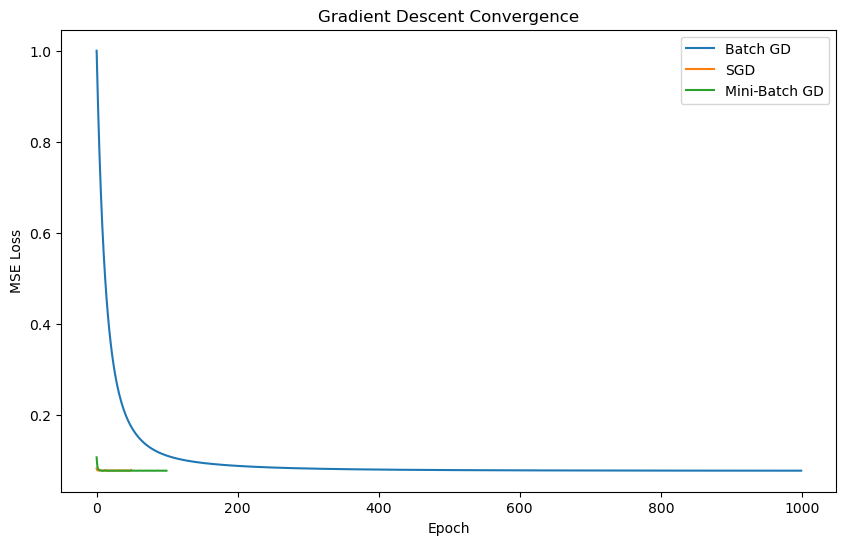

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(batch_losses,label='Batch GD')
plt.plot(sgd_losses,label='SGD')
plt.plot(mini_losses,label='Mini-Batch GD')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Convergence')
plt.legend()
plt.show()

Training Time Comparison

In [37]:
gd_time_comparison = pd.DataFrame({'Method': ['Batch GD','SGD','Mini-Batch GD'],
    'Training Time (seconds)': [batch_time,sgd_time,mini_time]})
display(gd_time_comparison)

,Method,Training Time (seconds)
0,Batch GD,0.071133
1,SGD,1.145776
2,Mini-Batch GD,0.189891


Performance Comparison

In [38]:
gd_models = {
    'Batch GD': batch_pred,
    'SGD': sgd_pred,
    'Mini-Batch GD': mini_pred}
gd_results = []
for name, predictions in gd_models.items():   
    mse = mean_squared_error(y_test_gd,predictions) 
    rmse = np.sqrt(mse) 
    mae = mean_absolute_error(y_test_gd,predictions)
    r2 = r2_score(y_test_gd,predictions)
    gd_results.append([name, mse,mae, rmse, r2])
gd_comparison = pd.DataFrame(gd_results,
    columns=['Method','MSE','MAE','RMSE','R²' ])
display(gd_comparison)

,Method,MSE,MAE,RMSE,R²
0,Batch GD,1.288829e+13,2.643369e+06,3.590027e+06,0.915832
1,SGD,1.333724e+13,2.659510e+06,3.652018e+06,0.912900
2,Mini-Batch GD,1.290690e+13,2.642581e+06,3.592618e+06,0.915710


# 📐 Bias–Variance & Model Diagnostics

🔍 Analyze Bias and Variance Across Simple, Multiple and Polynomial Regression

In [39]:
simple_train_pred = simple_model.predict(X_train_simple)
multiple_train_pred = multiple_model.predict(X_train)
poly_train_pred = poly_model.predict(X_train_poly)
models_bias_variance = []
models_data = [(
        'Simple Linear Regression',y_train_simple,simple_train_pred,y_test_simple,y_pred_simple),
    (
        'Multiple Linear Regression',y_train,multiple_train_pred,y_test,y_pred_multiple),
    (
        'Polynomial Regression',y_train_poly,poly_train_pred,y_test_poly,y_pred_poly
    )]
for name, yt, yp, yv, ypv in models_data:   
    train_r2 = r2_score(yt, yp)
    test_r2 = r2_score(yv, ypv)   
    train_rmse = np.sqrt(mean_squared_error(yt, yp))
    test_rmse = np.sqrt(mean_squared_error(yv, ypv)) 
    models_bias_variance.append([name,train_rmse,test_rmse,train_r2,test_r2,train_r2 - test_r2])
bias_variance_df = pd.DataFrame(models_bias_variance,
    columns=['Model','Train RMSE','Test RMSE','Train R²','Test R²','Train-Test R² Gap'])
display(bias_variance_df)

,Model,Train RMSE,Test RMSE,Train R²,Test R²,Train-Test R² Gap
0,Simple Linear Regression,8.104428e+06,8.184697e+06,0.572307,0.562520,0.009788
1,Multiple Linear Regression,3.400099e+06,3.548650e+06,0.924722,0.917761,0.006961
2,Polynomial Regression,8.102913e+06,8.183089e+06,0.572467,0.562692,0.009776


🔍 Explain How Model Complexity Affects Prediction Error

🔍 Identify Which Model Best Balances Bias and Variance

In [40]:
best_model_row = bias_variance_df.loc[bias_variance_df['Test RMSE'].idxmin()]
print("Best Model:")
print(best_model_row['Model'])
print("\nTest RMSE:",best_model_row['Test RMSE'])
print("Test R²:",best_model_row['Test R²'])

Best Model:
Multiple Linear Regression

Test RMSE: 3548650.2904805443
Test R²: 0.9177606877509896


# 🧾 Final Analysis & Reporting

🔍 Summarize Findings in a Short Report

In [41]:
print("=" * 60)
print("FINAL MODEL ANALYSIS")
print("=" * 60)

print("\nModel Comparison:")
display(bias_variance_df)
best_model = bias_variance_df.loc[bias_variance_df['Test RMSE'].idxmin()]

print("\nBest Performing Model:")
print(best_model['Model'])

print("\nBest Model Test RMSE:")
print(best_model['Test RMSE'])

print("\nBest Model Test R²:")
print(best_model['Test R²'])

print("\nGradient Descent Comparison:")
display(gd_comparison)

FINAL MODEL ANALYSIS

Model Comparison:


,Model,Train RMSE,Test RMSE,Train R²,Test R²,Train-Test R² Gap
0,Simple Linear Regression,8.104428e+06,8.184697e+06,0.572307,0.562520,0.009788
1,Multiple Linear Regression,3.400099e+06,3.548650e+06,0.924722,0.917761,0.006961
2,Polynomial Regression,8.102913e+06,8.183089e+06,0.572467,0.562692,0.009776



Best Performing Model:
Multiple Linear Regression

Best Model Test RMSE:
3548650.2904805443

Best Model Test R²:
0.9177606877509896

Gradient Descent Comparison:


,Method,MSE,MAE,RMSE,R²
0,Batch GD,1.288829e+13,2.643369e+06,3.590027e+06,0.915832
1,SGD,1.333724e+13,2.659510e+06,3.652018e+06,0.912900
2,Mini-Batch GD,1.290690e+13,2.642581e+06,3.592618e+06,0.915710


Evaluation Results and Final Conclusion

In [42]:
final_results = bias_variance_df.copy()
final_results.to_csv("model_evaluation_results.csv",index=False)
print("Model evaluation results saved successfully.")

Model evaluation results saved successfully.
